# E-commerce Sales Performance Analysis

Analyze e-commerce sales performance to understand revenue trends, product performance, and purchasing behavior.

**Business Objective**: Identify sales patterns, top-performing products, and customer purchasing trends to support business and marketing decisions.


## 1. Import Libraries

Import libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load data
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

## 2. Load Dataset

Load sales transaction data and review the dataset structure.

In [2]:
# 2) Basic cleaning
df = df.dropna(subset=["CustomerID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

## 3. Data Cleaning

Clean missing values and prepare the dataset for analysis.

In [3]:
# 3) Create sales column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Sales"] = df["Quantity"] * df["UnitPrice"]

/var/folders/y0/g_vvng7x6gn1ggql3qv6040m0000gn/T/ipykernel_7909/1933949450.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


## 4. Exploratory Data Analysis (EDA)

Explore sales trends, customer behavior, and product performance.

In [4]:
# 4) Monthly sales trend
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("YearMonth", as_index=False)["Sales"].sum()

print(monthly_sales.head())

  YearMonth       Sales
0   2010-12  572713.890
1   2011-01  569445.040
2   2011-02  447137.350
3   2011-03  595500.760
4   2011-04  469200.361


## 5. Sales Performance Analysis

Analyze sales metrics and business performance indicators.

In [5]:
# 5) Top 10 products by sales
top_products = (
    df.groupby("Description", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)

print(top_products)

                             Description      Sales
2319         PAPER CRAFT , LITTLE BIRDIE  168469.60
2767            REGENCY CAKESTAND 3 TIER  142592.95
3698  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
1762             JUMBO BAG RED RETROSPOT   85220.78
1992      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
2611                             POSTAGE   77803.96
2345                       PARTY BUNTING   68844.33
216        ASSORTED COLOUR BIRD ORNAMENT   56580.34
2130                              Manual   53779.93
2656                  RABBIT NIGHT LIGHT   51346.20


## 6. Visualization & Key Insights

Visualize findings and summarize key sales insights.

In [6]:
# 6) Country sales
country_sales = (
    df.groupby("Country", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)

print(country_sales)

           Country        Sales
35  United Kingdom  7308391.554
23     Netherlands   285446.340
10            EIRE   265545.900
14         Germany   228867.140
13          France   209024.050
0        Australia   138521.310
30           Spain    61577.110
32     Switzerland    56443.950
3          Belgium    41196.340
31          Sweden    38378.330


## 7. Business Recommendations

Provide practical recommendations based on sales trends.

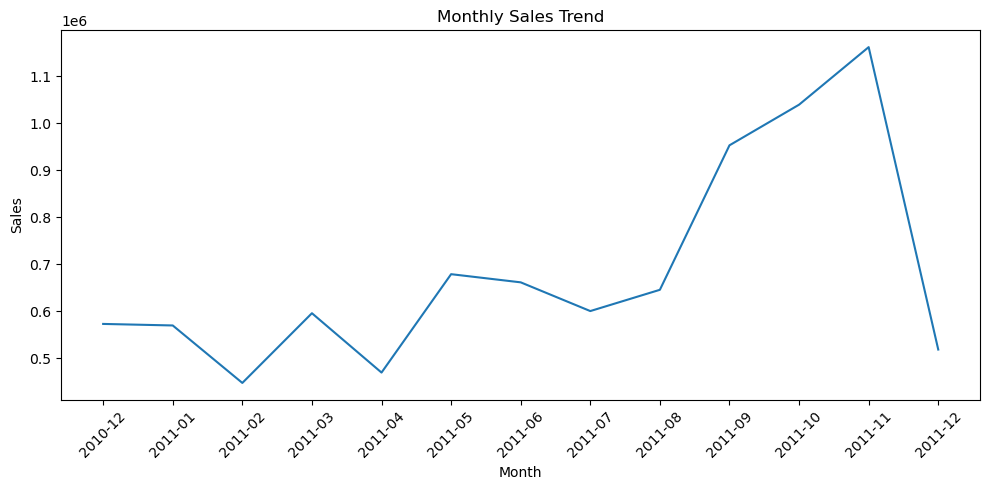

In [7]:
# 7) Plot monthly sales
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales"])
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## 8. Conclusion

Summarize findings and potential next steps.